In [1]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


filename = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
possible_paths = [
    filename,
    os.path.join("data", filename),
    os.path.join("..", "data", filename),
    os.path.join("..", filename),
    os.path.join(r"C:\Users\hzk26\customer-churn-analysis\data", filename),
    os.path.join(r"C:\Users\hzk26\customer-churn-analysis", filename)
]

csv_path = None
for path in possible_paths:
    if os.path.exists(path):
        csv_path = path
        break

if csv_path:
    print(f"File found at: {csv_path}")
    df = pd.read_csv(csv_path)
    print(f"Dataset successfully loaded! Shape: {df.shape}")
else:
    raise FileNotFoundError(f"Could not find {filename}. Current folder: {os.getcwd()}")

df.head()

File found at: C:\Users\hzk26\customer-churn-analysis\data\WA_Fn-UseC_-Telco-Customer-Churn.csv
Dataset successfully loaded! Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip(), errors='coerce')

print("Missing TotalCharges before fix:", df['TotalCharges'].isnull().sum())


df['TotalCharges'] = df['TotalCharges'].fillna(0.0)


print("Missing TotalCharges after fix:", df['TotalCharges'].isnull().sum())
print("\nKey numeric column statistics:")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().T)

Missing TotalCharges before fix: 11
Missing TotalCharges after fix: 0

Key numeric column statistics:
                 count         mean          std    min     25%      50%  \
tenure          7043.0    32.371149    24.559481   0.00    9.00    29.00   
MonthlyCharges  7043.0    64.761692    30.090047  18.25   35.50    70.35   
TotalCharges    7043.0  2279.734304  2266.794470   0.00  398.55  1394.55   

                    75%      max  
tenure            55.00    72.00  
MonthlyCharges    89.85   118.75  
TotalCharges    3786.60  8684.80  


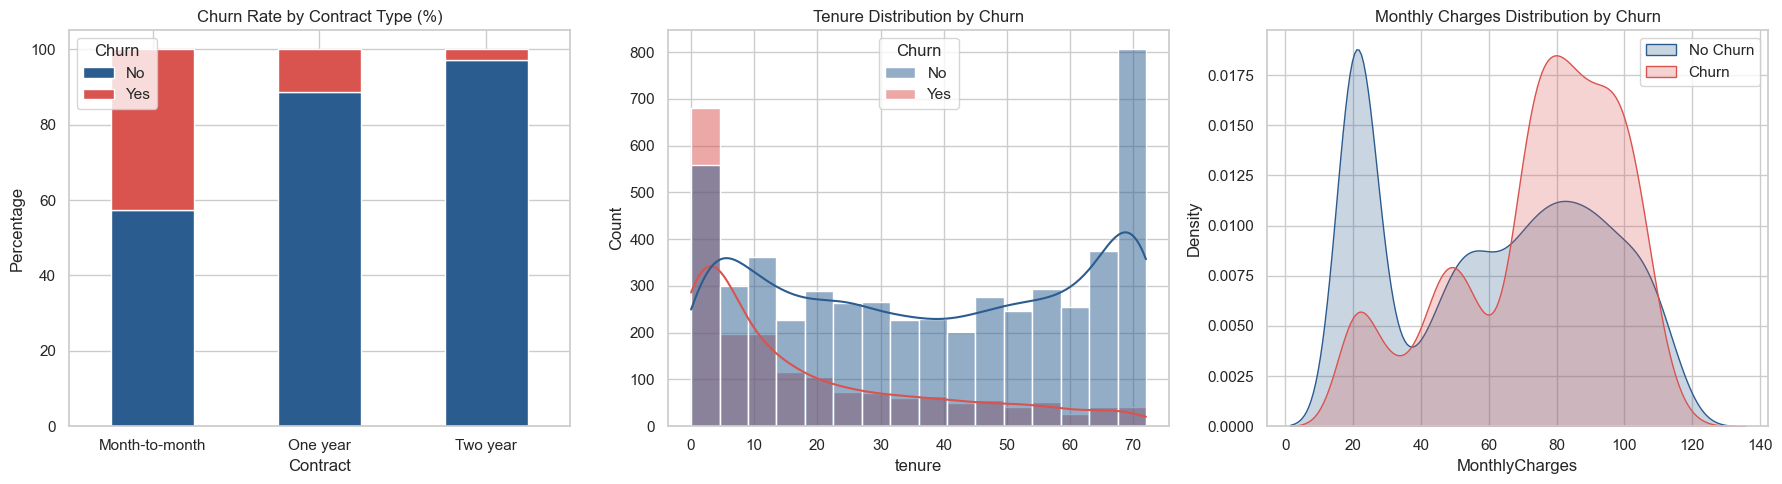

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
contract_churn.plot(kind='bar', stacked=True, ax=axes[0], color=['#2b5c8f', '#d9534f'])
axes[0].set_title('Churn Rate by Contract Type (%)')
axes[0].set_ylabel('Percentage')
axes[0].tick_params(axis='x', rotation=0)

sns.histplot(data=df, x='tenure', hue='Churn', kde=True, ax=axes[1], palette=['#2b5c8f', '#d9534f'])
axes[1].set_title('Tenure Distribution by Churn')

sns.kdeplot(data=df[df['Churn'] == 'No']['MonthlyCharges'], label='No Churn', ax=axes[2], fill=True, color='#2b5c8f')
sns.kdeplot(data=df[df['Churn'] == 'Yes']['MonthlyCharges'], label='Churn', ax=axes[2], fill=True, color='#d9534f')
axes[2].set_title('Monthly Charges Distribution by Churn')
axes[2].legend()

plt.tight_layout()
plt.show()

OSError: Cannot save file into a non-existent directory: '..\data'

In [6]:
import os

df_model = df.drop(columns=['customerID'])

df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)

df.to_csv('cleaned_telco_churn.csv', index=False)
print("Saved 'cleaned_telco_churn.csv' successfully to current folder!")

df_encoded = pd.get_dummies(df_model, drop_first=True)

print(f"Original columns: {df_model.shape[1]}")
print(f"Encoded columns: {df_encoded.shape[1]}")
print("\nTarget distribution:")
print(df_encoded['Churn'].value_counts(normalize=True))

df_encoded.head()

Saved 'cleaned_telco_churn.csv' successfully to current folder!
Original columns: 20
Encoded columns: 31

Target distribution:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("=== Logistic Regression Performance ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

print("\n=== Random Forest Performance ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

=== Logistic Regression Performance ===
ROC-AUC: 0.8422
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


=== Random Forest Performance ===
ROC-AUC: 0.8253
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.50      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



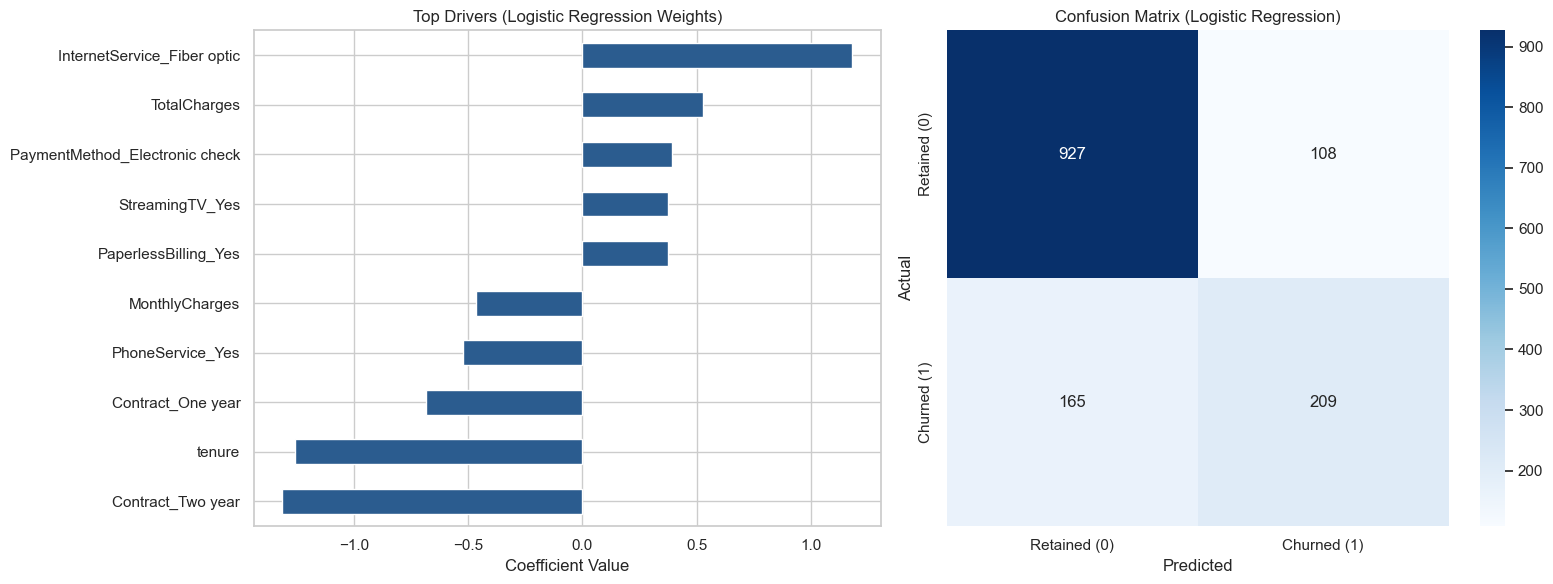


Top 5 factors increasing churn risk:
InternetService_Fiber optic       1.180666
TotalCharges                      0.527772
PaymentMethod_Electronic check    0.392775
StreamingTV_Yes                   0.374831
PaperlessBilling_Yes              0.374218
dtype: float64

Top 5 factors reducing churn risk (retention drivers):
Contract_Two year   -1.313803
tenure              -1.257131
Contract_One year   -0.683857
PhoneService_Yes    -0.520750
MonthlyCharges      -0.466504
dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
lr_coefs = pd.Series(lr_model.coef_[0], index=X.columns).sort_values()
top_lr = pd.concat([lr_coefs.head(5), lr_coefs.tail(5)])
top_lr.plot(kind='barh', ax=axes[0], color='#2b5c8f')
axes[0].set_title('Top Drivers (Logistic Regression Weights)')
axes[0].set_xlabel('Coefficient Value')
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Retained (0)', 'Churned (1)'],
            yticklabels=['Retained (0)', 'Churned (1)'])
axes[1].set_title('Confusion Matrix (Logistic Regression)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()
print("\nTop 5 factors increasing churn risk:")
print(lr_coefs.tail(5)[::-1])
print("\nTop 5 factors reducing churn risk (retention drivers):")
print(lr_coefs.head(5))

In [9]:
X_all_scaled = scaler.transform(X[num_cols])
X_full_scaled = X.copy()
X_full_scaled[num_cols] = X_all_scaled

df['Churn_Probability'] = lr_model.predict_proba(X_full_scaled)[:, 1]
df['Risk_Level'] = pd.cut(
    df['Churn_Probability'],
    bins=[0, 0.3, 0.7, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

export_filename = 'telco_churn_powerbi_ready.csv'
df.to_csv(export_filename, index=False)
print(f"Exported final file: {export_filename}")
print(df[['customerID', 'Contract', 'MonthlyCharges', 'Churn_Probability', 'Risk_Level']].head())

Exported final file: telco_churn_powerbi_ready.csv
   customerID        Contract  MonthlyCharges  Churn_Probability   Risk_Level
0  7590-VHVEG  Month-to-month           29.85           0.615319  Medium Risk
1  5575-GNVDE        One year           56.95           0.045163     Low Risk
2  3668-QPYBK  Month-to-month           53.85           0.299838     Low Risk
3  7795-CFOCW        One year           42.30           0.028516     Low Risk
4  9237-HQITU  Month-to-month           70.70           0.693423  Medium Risk


In [1]:
import os
print(os.path.abspath('telco_churn_powerbi_ready.csv'))

C:\Users\hzk26\telco_churn_powerbi_ready.csv
